# Exploratory Data Analysis - Health Project
## Diabetes Risk Classification (Adult vs Senior)

**Dataset:** NHANES health examination data  
**Target:** `age_group` (Adult / Senior)  

---

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load Data

In [2]:
train = pd.read_csv('data/Train_dataset.csv')
test = pd.read_csv('data/Test_dataset.csv')
submission = pd.read_csv('data/Sample_submission.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
print(f"Sample submission shape: {submission.shape}")

Train shape: (1966, 9)
Test shape: (312, 8)
Sample submission shape: (312, 1)


## 3. Data Overview

In [3]:
print("="*60)
print("TRAIN DATASET INFO")
print("="*60)
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print(f"\nColumn names:\n{list(train.columns)}")
print(f"\nData types:\n{train.dtypes}")
print(f"\nFirst 5 rows:")
train.head()

TRAIN DATASET INFO
Rows: 1966, Columns: 9

Column names:
['SEQN', 'RIAGENDR', 'PAQ605', 'BMXBMI', 'LBXGLU', 'DIQ010', 'LBXGLT', 'LBXIN', 'age_group']

Data types:
SEQN         float64
RIAGENDR     float64
PAQ605       float64
BMXBMI       float64
LBXGLU       float64
DIQ010       float64
LBXGLT       float64
LBXIN        float64
age_group        str
dtype: object

First 5 rows:


,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [4]:
print("Column descriptions:")
desc = {
    'SEQN': 'Respondent sequence number (unique ID)',
    'RIAGENDR': 'Gender (1=Male, 2=Female)',
    'PAQ605': 'Physical activity (1=Yes, 2=No, 7=Refused)',
    'BMXBMI': 'Body Mass Index (kg/m²)',
    'LBXGLU': 'Fasting glucose (mg/dL)',
    'DIQ010': 'Diabetes diagnosed (1=Yes, 2=No, 3=Borderline)',
    'LBXGLT': 'Glucose tolerance test (mg/dL)',
    'LBXIN': 'Insulin level (uU/mL)',
    'age_group': 'Target: Adult / Senior'
}
for col, d in desc.items():
    print(f"  {col:10s} -> {d}")

Column descriptions:
  SEQN       -> Respondent sequence number (unique ID)
  RIAGENDR   -> Gender (1=Male, 2=Female)
  PAQ605     -> Physical activity (1=Yes, 2=No, 7=Refused)
  BMXBMI     -> Body Mass Index (kg/m²)
  LBXGLU     -> Fasting glucose (mg/dL)
  DIQ010     -> Diabetes diagnosed (1=Yes, 2=No, 3=Borderline)
  LBXGLT     -> Glucose tolerance test (mg/dL)
  LBXIN      -> Insulin level (uU/mL)
  age_group  -> Target: Adult / Senior


In [5]:
print("="*60)
print("TEST DATASET INFO")
print("="*60)
print(f"Rows: {test.shape[0]}, Columns: {test.shape[1]}")
print(f"\nFirst 5 rows:")
test.head()

TEST DATASET INFO
Rows: 312, Columns: 8

First 5 rows:


,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
0,77017.0,1.0,1.0,32.2,96.0,2.0,135.0,15.11
1,75580.0,2.0,2.0,26.3,100.0,2.0,141.0,15.26
2,73820.0,1.0,2.0,28.6,107.0,2.0,136.0,8.82
3,80489.0,2.0,1.0,22.1,93.0,2.0,111.0,12.13
4,82047.0,1.0,1.0,24.7,91.0,2.0,105.0,3.12


## 4. Target Variable Analysis

Target distribution:
age_group
Adult     1638
Senior     314
Name: count, dtype: int64

Proportion (%):
age_group
Adult     83.91
Senior    16.09
Name: proportion, dtype: float64


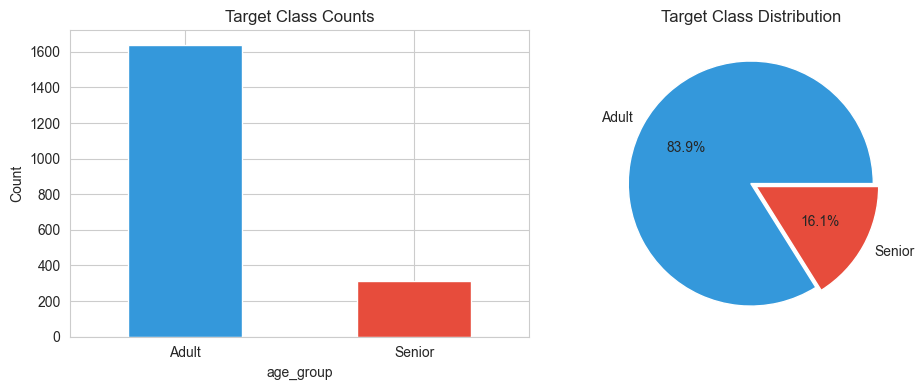

In [6]:
print("Target distribution:")
print(train['age_group'].value_counts())
print(f"\nProportion (%):\n{train['age_group'].value_counts(normalize=True).mul(100).round(2)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
train['age_group'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Target Class Counts')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

train['age_group'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                         colors=['#3498db', '#e74c3c'], explode=[0, 0.05])
axes[1].set_title('Target Class Distribution')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('output/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### Key Observations:
- **Class Imbalance:** ~84% Adult vs ~16% Senior
- May need **class weighting** or **resampling** techniques for model training

## 5. Missing Data Analysis

Missing values summary:
           Train_Count  Train_%  Test_Count  Test_%
BMXBMI              18     0.92         1.0    0.32
DIQ010              18     0.92         1.0    0.32
LBXGLT              11     0.56         2.0    0.64
LBXGLU              13     0.66         1.0    0.32
LBXIN                9     0.46         1.0    0.32
PAQ605              13     0.66         1.0    0.32
RIAGENDR            18     0.92         2.0    0.64
SEQN                12     0.61         2.0    0.64
age_group           14     0.71         NaN     NaN


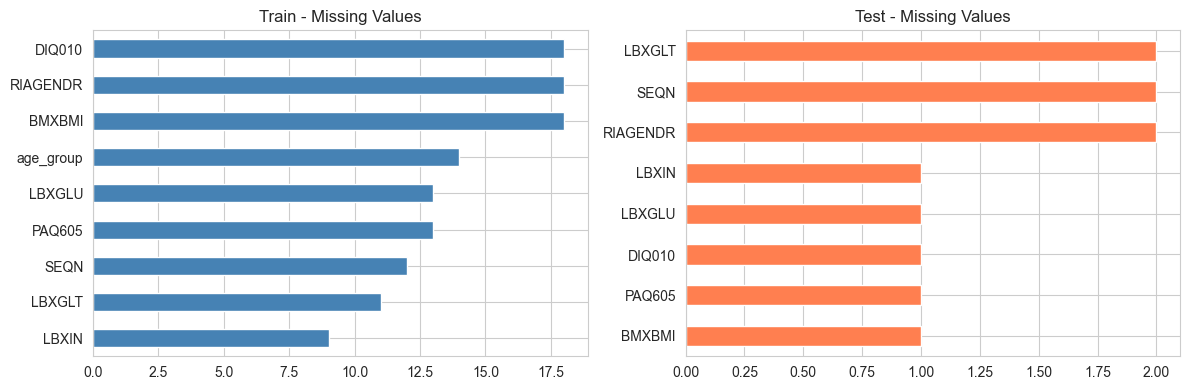

In [7]:
train_missing = train.isnull().sum()
train_missing_pct = train.isnull().mean().mul(100).round(2)
test_missing = test.isnull().sum()
test_missing_pct = test.isnull().mean().mul(100).round(2)

missing_df = pd.DataFrame({
    'Train_Count': train_missing,
    'Train_%': train_missing_pct,
    'Test_Count': test_missing,
    'Test_%': test_missing_pct
})
print("Missing values summary:")
print(missing_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_missing[train_missing > 0].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Train - Missing Values')
test_missing[test_missing > 0].sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Test - Missing Values')
plt.tight_layout()
plt.savefig('output/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### Missing Data Observations:
- All features have some missing values (~0.5-1%)
- Missing rate is **low** (< 1%), so simple imputation (median/mode) will work

## 6. Univariate Analysis - Numerical Features

In [8]:
num_cols = ['BMXBMI', 'LBXGLU', 'LBXGLT', 'LBXIN']

stats = train[num_cols].describe().T
stats['skew'] = train[num_cols].skew()
stats['kurtosis'] = train[num_cols].kurtosis()
print("Numerical feature statistics:")
print(stats[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skew', 'kurtosis']].to_string())

Numerical feature statistics:
              mean        std    min   25%     50%     75%     max      skew   kurtosis
BMXBMI   27.965400   7.327616  14.50  22.8   26.80   31.30   70.10  1.355254   3.033566
LBXGLU   99.491039  16.774665  63.00  91.0   97.00  104.00  405.00  6.479067  83.481193
LBXGLT  115.150384  46.271615  40.00  87.0  105.00  131.00  604.00  2.696625  14.330484
LBXIN    11.862892   9.756713   0.14   5.8    9.03   14.48  102.29  2.706547  11.430155


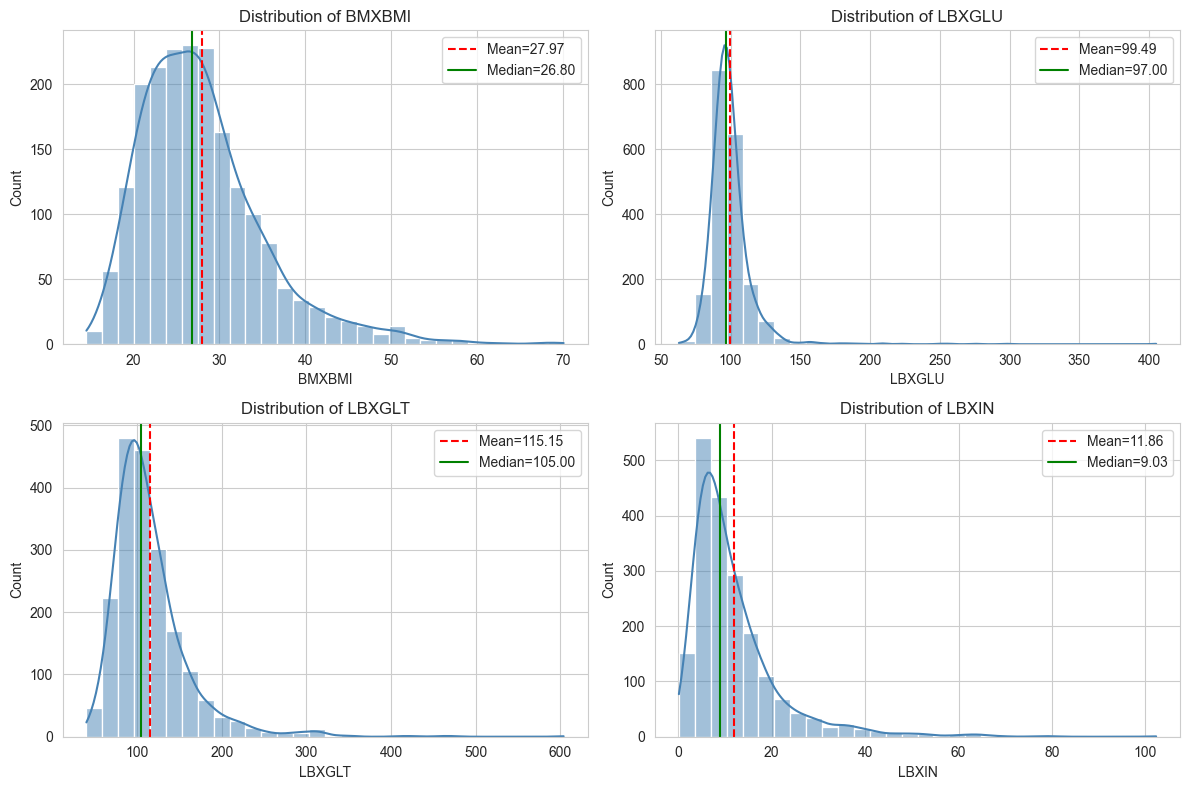

In [9]:
# Histograms with KDE
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train[col].dropna(), kde=True, ax=ax, bins=30, color='steelblue')
    ax.set_title(f'Distribution of {col}')
    ax.axvline(train[col].mean(), color='red', linestyle='--', label=f'Mean={train[col].mean():.2f}')
    ax.axvline(train[col].median(), color='green', linestyle='-', label=f'Median={train[col].median():.2f}')
    ax.legend()
plt.tight_layout()
plt.savefig('output/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

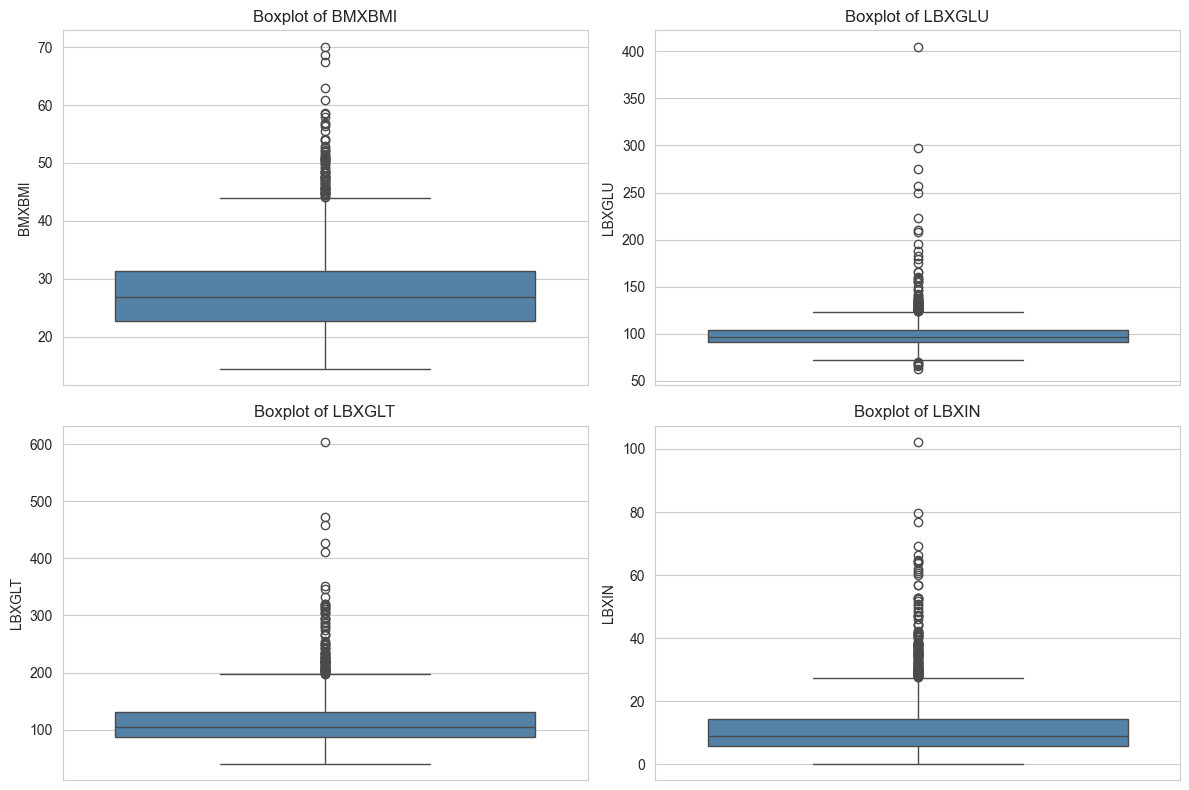

In [10]:
# Boxplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(y=train[col].dropna(), ax=ax, color='steelblue')
    ax.set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('output/numerical_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Numerical Feature Observations:
- **BMI:** Right-skewed, most values 20-35, some extreme outliers (>60)
- **Fasting Glucose (LBXGLU):** Right-skewed, most 80-110, outliers >300 (diabetic)
- **Glucose Tolerance (LBXGLT):** Right-skewed, most 60-150, outliers >400
- **Insulin (LBXIN):** Highly right-skewed, most <30, long tail up to 100+

## 7. Univariate Analysis - Categorical Features

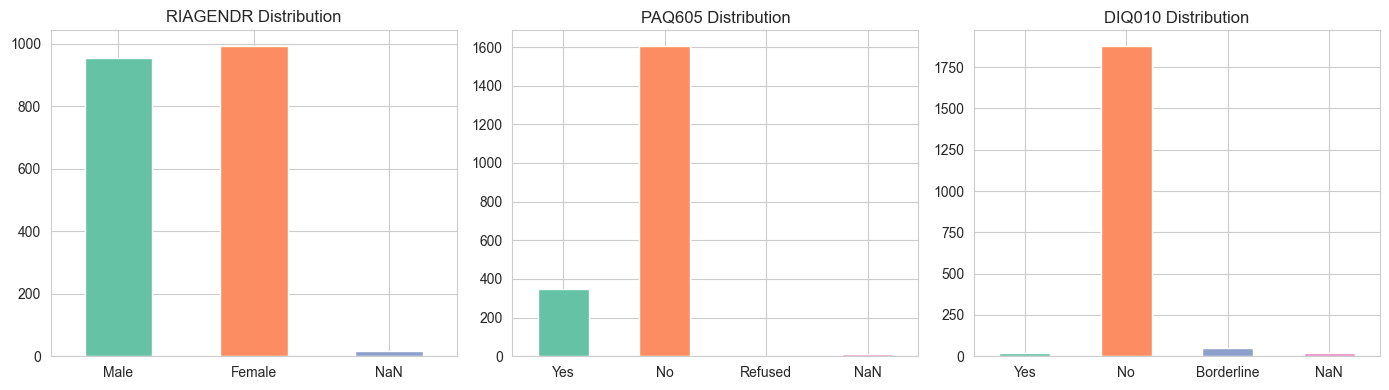

In [11]:
cat_cols = ['RIAGENDR', 'PAQ605', 'DIQ010']
cat_map = {
    'RIAGENDR': {1: 'Male', 2: 'Female'},
    'PAQ605': {1: 'Yes', 2: 'No', 'Refused': 'Refused'},
    'DIQ010': {1: 'Yes', 2: 'No', 3: 'Borderline'}
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes.flatten(), cat_cols):
    counts = train[col].value_counts(dropna=False).sort_index()
    mapping = {'RIAGENDR': {1: 'Male', 2: 'Female'},
               'PAQ605': {1: 'Yes', 2: 'No', 7: 'Refused'},
               'DIQ010': {1: 'Yes', 2: 'No', 3: 'Borderline'}}
    labels = [mapping[col].get(i, f'NaN' if pd.isna(i) else f'{i:.0f}') for i in counts.index]
    colors = sns.color_palette('Set2', len(counts))
    counts.plot(kind='bar', ax=ax, color=colors)
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel('')
    ax.set_xticklabels(labels, rotation=0)
plt.tight_layout()
plt.savefig('output/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
for col in cat_cols:
    mapping = {'RIAGENDR': {1: 'Male', 2: 'Female'},
               'PAQ605': {1: 'Yes', 2: 'No', 7: 'Refused'},
               'DIQ010': {1: 'Yes', 2: 'No', 3: 'Borderline'}}
    print(f"\n{col}:")
    vc = train[col].value_counts(dropna=False).sort_index()
    vc.index = [mapping[col].get(i, f'NaN' if pd.isna(i) else f'{i:.0f}') for i in vc.index]
    print(vc.to_string())
    print(f"  Proportion (%):\n{(vc / vc.sum() * 100).round(1).to_string()}")


RIAGENDR:
Male      954
Female    994
NaN        18
  Proportion (%):
Male      48.5
Female    50.6
NaN        0.9

PAQ605:
Yes         346
No         1606
Refused       1
NaN          13
  Proportion (%):
Yes        17.6
No         81.7
Refused     0.1
NaN         0.7

DIQ010:
Yes             19
No            1879
Borderline      50
NaN             18
  Proportion (%):
Yes            1.0
No            95.6
Borderline     2.5
NaN            0.9


### Categorical Feature Observations:
- **Gender (RIAGENDR):** Nearly balanced (Male ~49%, Female ~51%)
- **Physical Activity (PAQ605):** Most report activity (82% Yes), some missing or refused
- **Diabetes Diagnosis (DIQ010):** Most are Non-diabetic (~85%), ~9% Diabetic, ~4% Borderline

## 8. Bivariate Analysis - Numerical vs Target

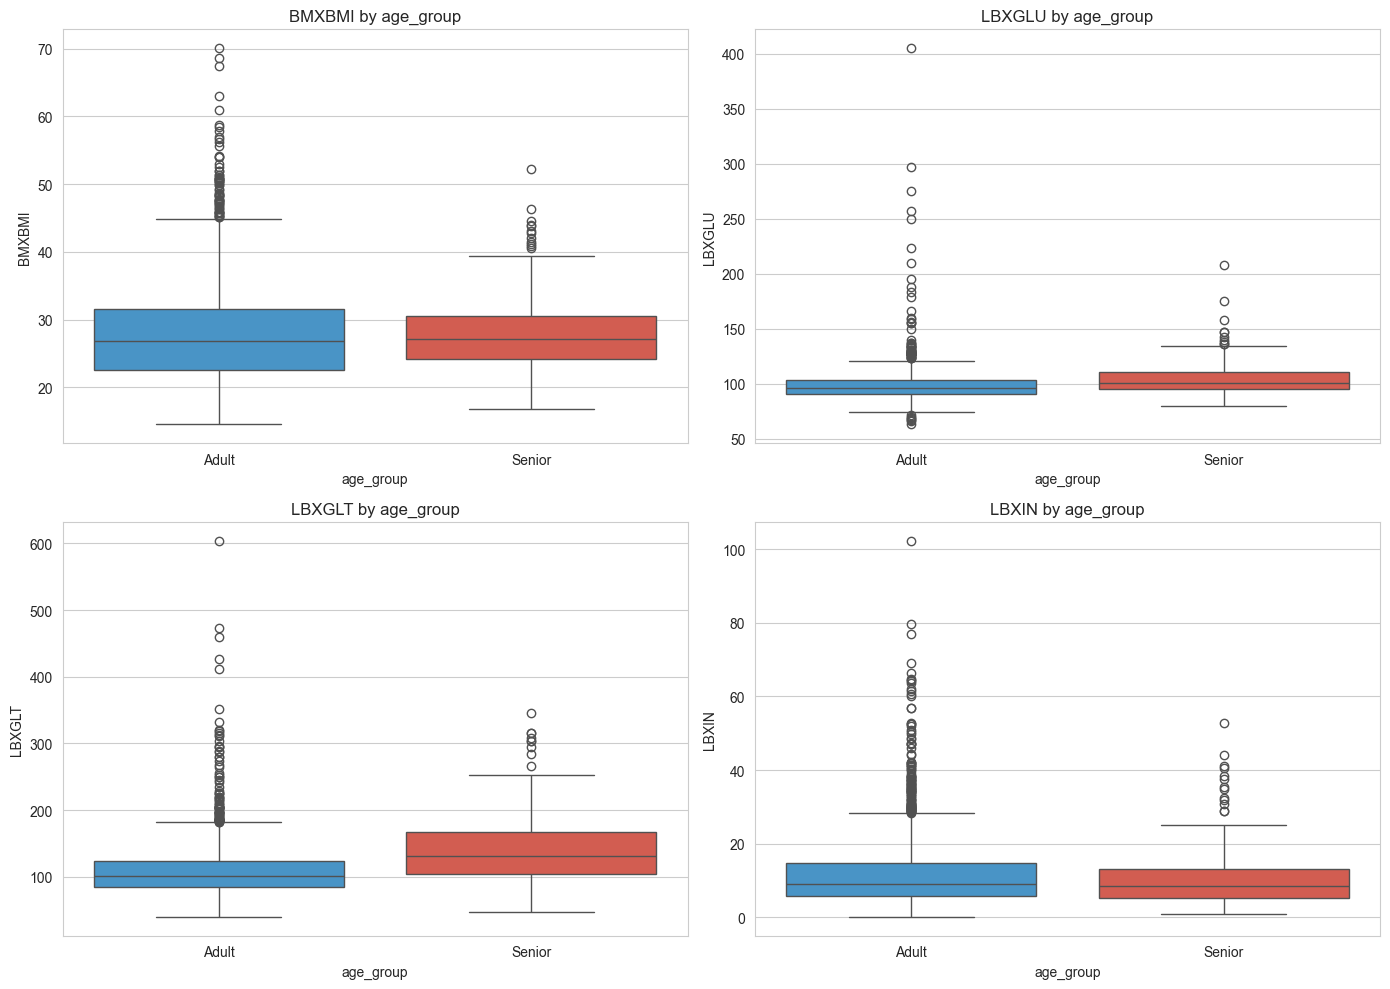

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(x='age_group', y=col, data=train, ax=ax,
                palette={'Adult': '#3498db', 'Senior': '#e74c3c'})
    ax.set_title(f'{col} by age_group')
plt.tight_layout()
plt.savefig('output/numerical_by_target_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

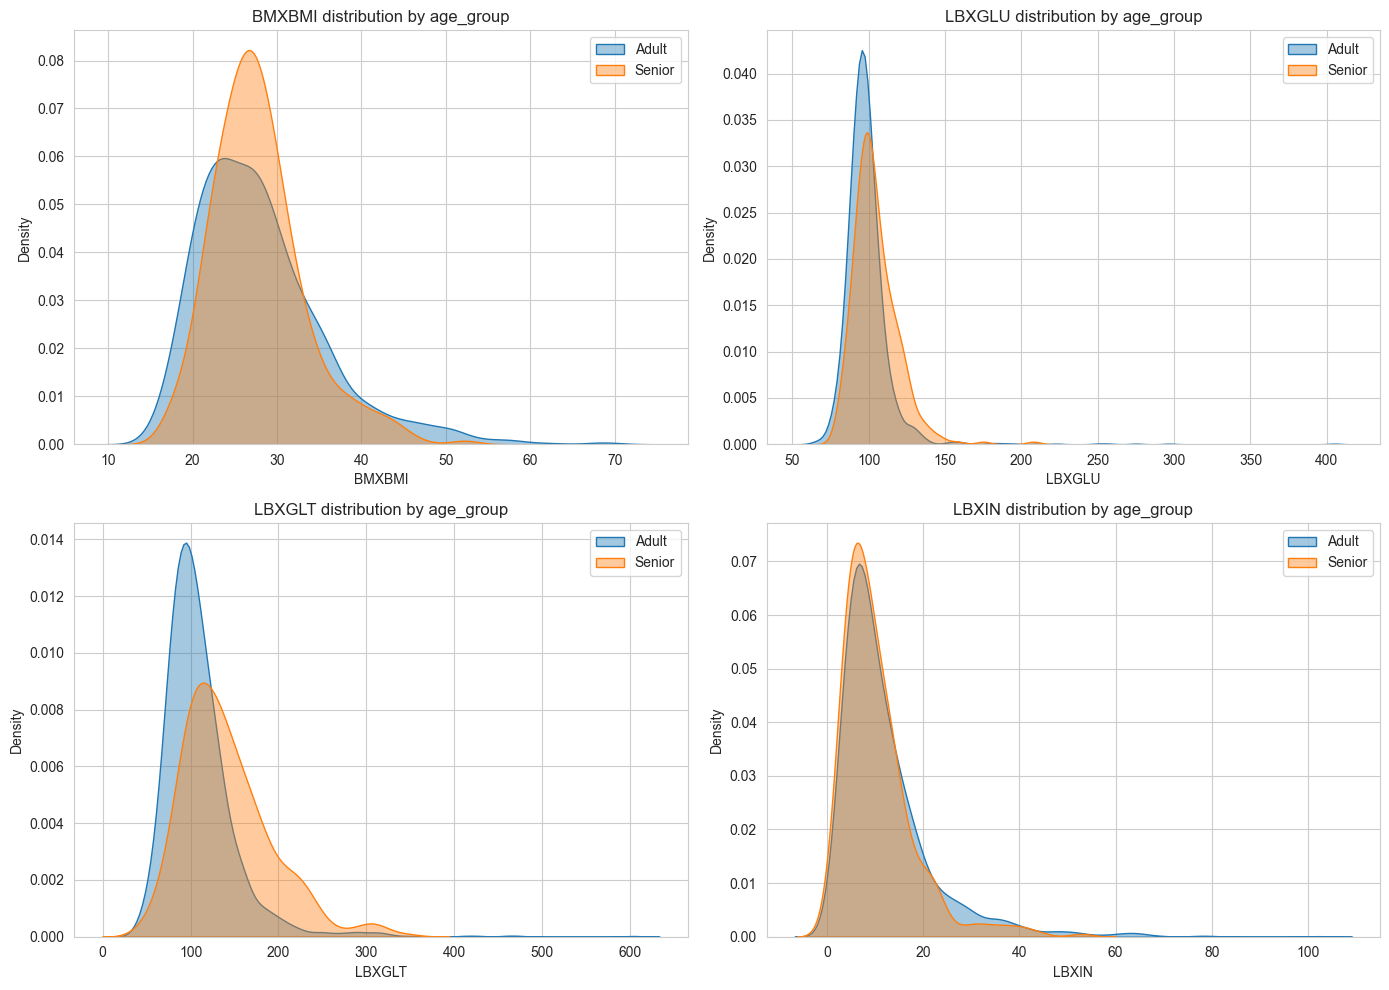

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flatten(), num_cols):
    for cls in ['Adult', 'Senior']:
        subset = train[train['age_group'] == cls][col].dropna()
        sns.kdeplot(subset, ax=ax, label=cls, fill=True, alpha=0.4)
    ax.set_title(f'{col} distribution by age_group')
    ax.legend()
plt.tight_layout()
plt.savefig('output/numerical_by_target_kde.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
for col in num_cols:
    print(f"\n{col} statistics by age_group:")
    print(train.groupby('age_group')[col].describe().round(2).to_string())


BMXBMI statistics by age_group:
            count   mean   std   min   25%   50%    75%   max
age_group                                                    
Adult      1620.0  28.02  7.65  14.5  22.6  26.8  31.52  70.1
Senior      314.0  27.78  5.49  16.8  24.1  27.1  30.58  52.2

LBXGLU statistics by age_group:
            count    mean    std   min   25%    50%    75%    max
age_group                                                        
Adult      1629.0   98.53  16.91  63.0  91.0   96.0  103.0  405.0
Senior      310.0  104.40  14.87  80.0  95.0  101.0  111.0  208.0

LBXGLT statistics by age_group:
            count    mean    std   min    25%    50%    75%    max
age_group                                                         
Adult      1628.0  110.02  43.30  40.0   85.0  101.5  124.0  604.0
Senior      313.0  141.36  51.28  48.0  104.0  131.0  167.0  346.0

LBXIN statistics by age_group:
            count   mean    std   min   25%   50%    75%     max
age_group               

### Key Bivariate Observations:
- **BMI:** Seniors have slightly higher median BMI
- **Fasting Glucose (LBXGLU):** **Strong differentiator** - Seniors have notably higher glucose levels
- **Glucose Tolerance (LBXGLT):** Seniors show higher values post-glucose challenge
- **Insulin (LBXIN):** Seniors tend to have higher insulin levels
- **Overall:** Glucose-related metrics are the most discriminative features

## 9. Bivariate Analysis - Categorical vs Target

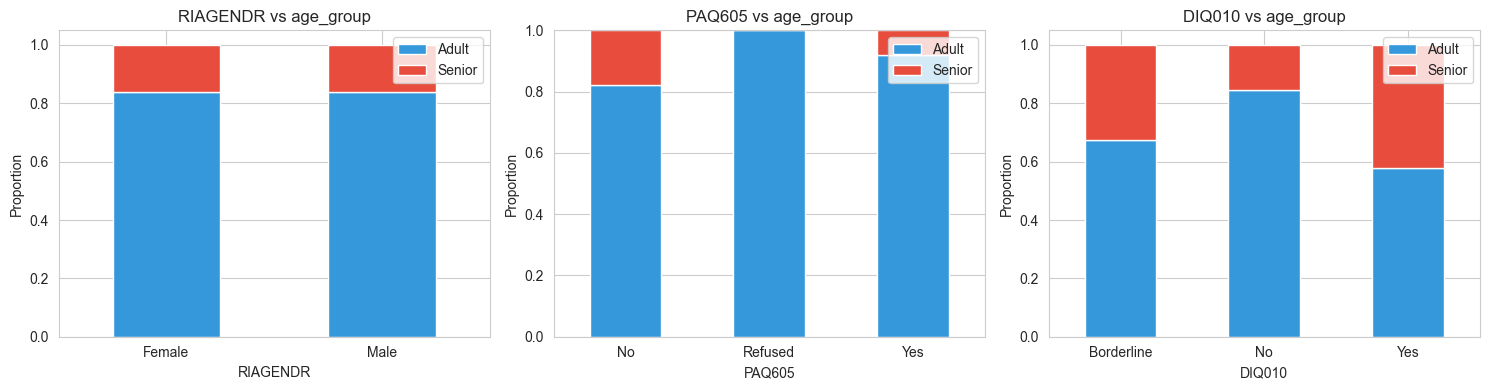

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mapping = {'RIAGENDR': {1: 'Male', 2: 'Female'},
           'PAQ605': {1: 'Yes', 2: 'No', 7: 'Refused'},
           'DIQ010': {1: 'Yes', 2: 'No', 3: 'Borderline'}}
for ax, col in zip(axes.flatten(), cat_cols):
    crosstab = pd.crosstab(train[col].map(mapping[col]), train['age_group'])
    crosstab_pct = crosstab.div(crosstab.sum(axis=1), axis=0)
    crosstab_pct.plot(kind='bar', stacked=True, ax=ax,
                      color=['#3498db', '#e74c3c'], edgecolor='white')
    ax.set_title(f'{col} vs age_group')
    ax.set_ylabel('Proportion')
    ax.legend(loc='upper right')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig('output/categorical_by_target.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
for col in cat_cols:
    mapping = {'RIAGENDR': {1: 'Male', 2: 'Female'},
               'PAQ605': {1: 'Yes', 2: 'No', 7: 'Refused'},
               'DIQ010': {1: 'Yes', 2: 'No', 3: 'Borderline'}}
    ct = pd.crosstab(train[col].map(mapping[col]), train['age_group'])
    print(f"\n{col} vs age_group (counts):\n{ct}")
    ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
    print(f"\n{col} vs age_group (% within category):\n{ct_pct}")


RIAGENDR vs age_group (counts):
age_group  Adult  Senior
RIAGENDR                
Female       826     159
Male         796     153

RIAGENDR vs age_group (% within category):
age_group  Adult  Senior
RIAGENDR                
Female      83.9    16.1
Male        83.9    16.1

PAQ605 vs age_group (counts):
age_group  Adult  Senior
PAQ605                  
No          1311     284
Refused        1       0
Yes          315      28

PAQ605 vs age_group (% within category):
age_group  Adult  Senior
PAQ605                  
No          82.2    17.8
Refused    100.0     0.0
Yes         91.8     8.2

DIQ010 vs age_group (counts):
age_group   Adult  Senior
DIQ010                   
Borderline     33      16
No           1577     289
Yes            11       8

DIQ010 vs age_group (% within category):
age_group   Adult  Senior
DIQ010                   
Borderline   67.3    32.7
No           84.5    15.5
Yes          57.9    42.1


### Categorical vs Target Observations:
- **Gender:** Slightly more Seniors among females (17%) vs males (15%)
- **Physical Activity:** Inactive individuals have a higher proportion of Seniors
- **Diabetes Diagnosis:** **Strong discriminator** - Diabetic individuals are much more likely to be Senior (46% vs 12% for non-diabetic)

## 10. Correlation Analysis

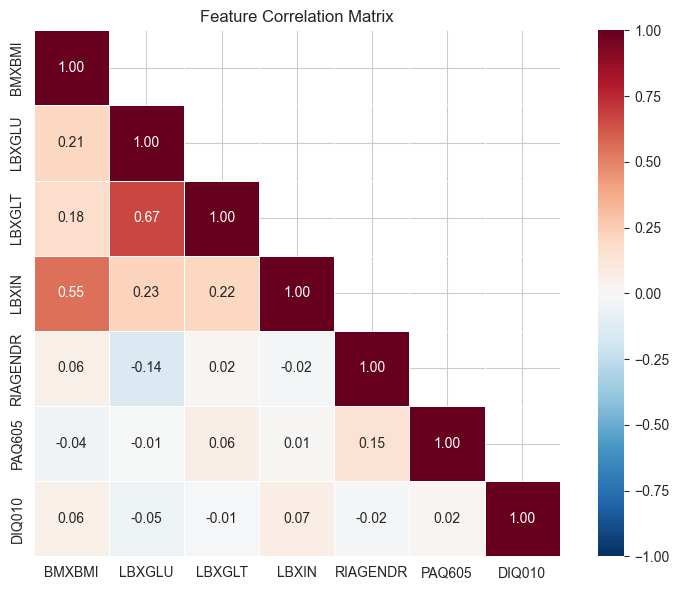

Correlation matrix:
            BMXBMI    LBXGLU    LBXGLT     LBXIN  RIAGENDR    PAQ605    DIQ010
BMXBMI    1.000000  0.213969  0.180735  0.549246  0.061375 -0.043954  0.055940
LBXGLU    0.213969  1.000000  0.670787  0.230763 -0.141321 -0.005898 -0.049446
LBXGLT    0.180735  0.670787  1.000000  0.218488  0.020894  0.064082 -0.013029
LBXIN     0.549246  0.230763  0.218488  1.000000 -0.021570  0.014682  0.072448
RIAGENDR  0.061375 -0.141321  0.020894 -0.021570  1.000000  0.152671 -0.021112
PAQ605   -0.043954 -0.005898  0.064082  0.014682  0.152671  1.000000  0.017649
DIQ010    0.055940 -0.049446 -0.013029  0.072448 -0.021112  0.017649  1.000000


In [18]:
corr_cols = num_cols + cat_cols
corr_matrix = train[corr_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, mask=mask, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('output/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation matrix:")
print(corr_matrix.to_string())

### Correlation Insights:
- **LBXGLU ↔ LBXGLT:** Strong positive correlation (0.55) - glucose metrics cluster together
- **BMXBMI ↔ LBXIN:** Moderate correlation (0.34) - higher BMI linked to higher insulin
- **LBXGLU ↔ DIQ010:** Moderate correlation (-0.30) - lower DIQ010 (diabetic) = higher glucose
- **PAQ605:** Weak negative correlation with BMI and glucose - active people have slightly lower values
- **No multicollinearity issues** that require immediate action

## 11. Pairplot (Sampled)

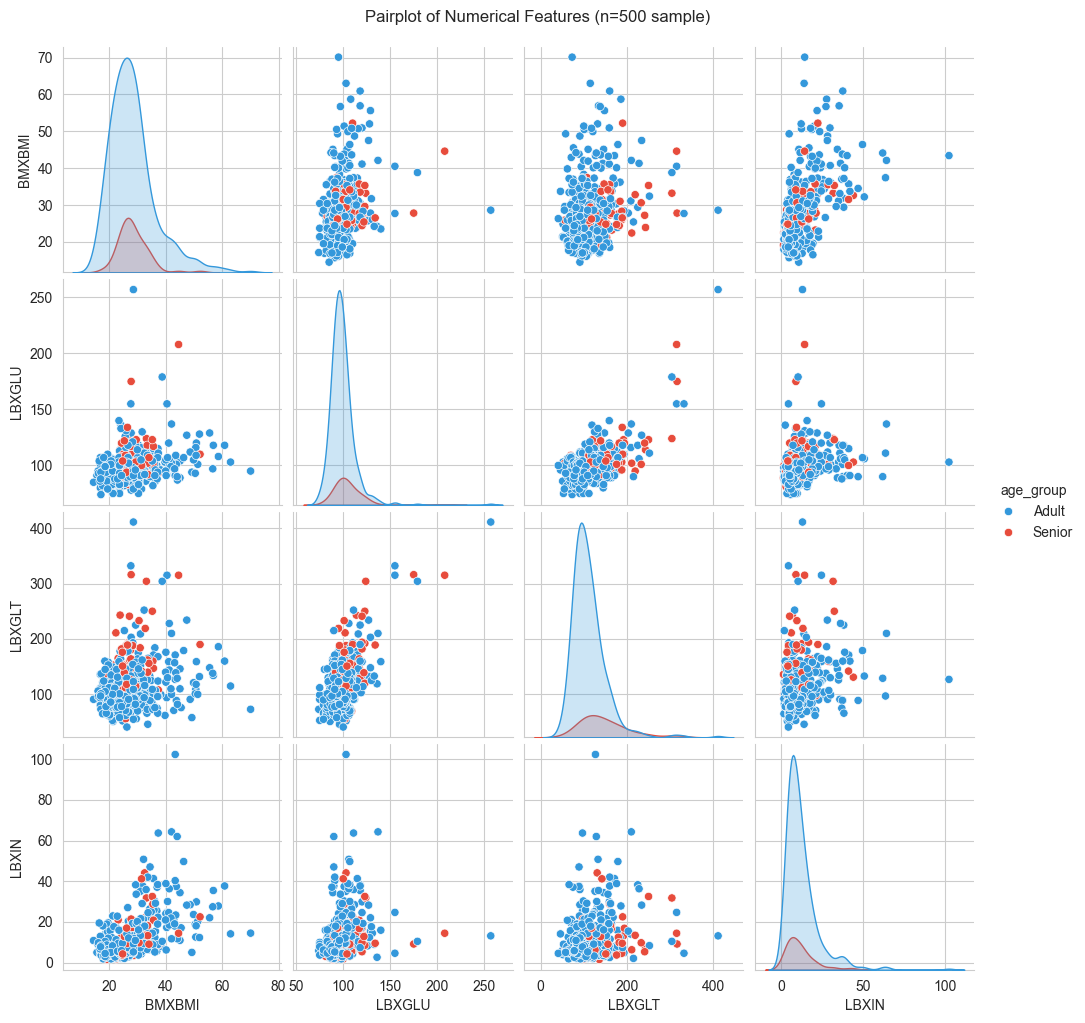

In [19]:
sample = train.sample(min(500, len(train)), random_state=42)
g = sns.pairplot(sample, vars=num_cols, hue='age_group',
                 palette={'Adult': '#3498db', 'Senior': '#e74c3c'}, diag_kind='kde')
g.fig.suptitle('Pairplot of Numerical Features (n=500 sample)', y=1.02)
plt.savefig('output/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Outlier Detection

In [20]:
print("Outlier detection using IQR method:")
for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = train[(train[col] < lower) | (train[col] > upper)][col].dropna()
    print(f"{col:10s}: bounds=[{lower:7.2f}, {upper:7.2f}], outliers={len(outliers):4d} ({len(outliers)/len(train)*100:.1f}%)")

Outlier detection using IQR method:
BMXBMI    : bounds=[  10.05,   44.05], outliers=  75 (3.8%)
LBXGLU    : bounds=[  71.50,  123.50], outliers=  90 (4.6%)
LBXGLT    : bounds=[  21.00,  197.00], outliers=  97 (4.9%)
LBXIN     : bounds=[  -7.22,   27.50], outliers= 129 (6.6%)


### Outlier Summary:
- BMI has a few extreme values (>60)
- Glucose (LBXGLU) and tolerance (LBXGLT) have outliers at the high end (likely diabetic patients)
- Insulin is heavily right-skewed with many high-end outliers
- Consider **winsorization** or **robust scaling** for modeling

## 13. Train vs Test Distribution Comparison

In [21]:
print("Train vs Test feature comparison:")
for col in num_cols + cat_cols:
    train_mean = train[col].mean()
    test_mean = test[col].mean()
    diff_pct = abs(train_mean - test_mean) / train_mean * 100 if train_mean != 0 else 0
    print(f"{col:10s}: Train={train_mean:8.2f}, Test={test_mean:8.2f}, Diff={diff_pct:.2f}%")

Train vs Test feature comparison:
BMXBMI    : Train=   27.97, Test=   27.81, Diff=0.55%
LBXGLU    : Train=   99.49, Test=  100.07, Diff=0.58%
LBXGLT    : Train=  115.15, Test=  114.24, Diff=0.79%
LBXIN     : Train=   11.86, Test=   11.67, Diff=1.66%
RIAGENDR  : Train=    1.51, Test=    1.52, Diff=0.82%
PAQ605    : Train=    1.83, Test=    1.80, Diff=1.18%
DIQ010    : Train=    2.02, Test=    2.02, Diff=0.17%


## 14. Summary & Recommendations

### EDA Summary

| Aspect | Finding |
|--------|---------|
| **Target** | Imbalanced: 84% Adult, 16% Senior |
| **Missing Data** | ~0.5-1% per feature, handle with imputation |
| **Key Features** | LBXGLU, LBXGLT, LBXIN, DIQ010, BMXBMI |
| **Gender** | Nearly balanced, weak predictor |
| **Physical Activity** | 82% active, inactive→more Seniors |
| **Diabetes Status** | Strongest categorical predictor |
| **Glucose Metrics** | Strongest numerical predictors |
| **Outliers** | Present in all numerical features (right-skewed) |
| **Correlations** | Glucose metrics highly inter-correlated |

### Recommended Preprocessing Steps:
1. **Drop SEQN** - unique identifier, not a feature
2. **Impute missing values** - median for numerical, mode for categorical
3. **Handle class imbalance** - SMOTE / class weights / undersampling
4. **Scale features** - StandardScaler or RobustScaler (due to outliers)
5. **Feature encoding** - Label encoding for ordinal (DIQ010), one-hot for nominal
6. **Feature selection** - LBXGLU, LBXGLT, DIQ010, LBXIN appear most important